# S8 tracking-feasibility correction

## tl;dr

The 2 s exact-bearing control cannot confirm (3 reception groups); the predeclared 4.5 s control confirms at 2.5793125 s and accepts 9 later updates across 3 distinct frame groups. In the held-out audio pilot, **10/16 method-session runs confirm**, with **90 accepted / 20 rejected** post-initialization updates. The remaining 6/16 are explicitly `computational_budget_exceeded`, including one accurate broadband/-6 dB session: the frozen work cap loses availability. Valid runs have estimates for about 50.36% of the measured publication span; absent estimates have no position/velocity error or conditional coverage. Two original evaluation sessions do not support a population-tail claim.


## Context & Methods

### Key assumptions

Read `S8_TRACKING_FEASIBILITY_PROTOCOL.md`. Same three station poses, CV trajectories, 48 kHz, 1024/512 frames, stride 64, Qc, NIS gates, source sessions and split seeds as the historical pilot. Duration is 4.5 s. The explicitly enabled initialization work budget is four nonlinear batch fits per generation. Recorded and broadband members have identical physical/noise random coordinates but separate calibration families. The recorded source remains an emitted-waveform approximation, not an SPL or range standard.


In [1]:
from pathlib import Path
import csv
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'results'
PREFIX = 's8_tracking_feasibility_'
def rows(name):
    with (RESULTS / name).open(encoding='utf-8', newline='') as source:
        return list(csv.DictReader(source))
controls = rows(PREFIX + 'schedule_control.csv')
support = rows(PREFIX + 'source_support.csv')
sessions = rows(PREFIX + 'session_results.csv')
summary = rows(PREFIX + 'summary.csv')
time_coverage = rows(PREFIX + 'time_coverage.csv')
calibration = rows(PREFIX + 'calibration.csv')
bearings = rows(PREFIX + 'bearing_results.csv')
tracking = rows(PREFIX + 'tracking_results.csv')
updates = rows(PREFIX + 'update_results.csv')
historical = rows('independent_recordings_session_results.csv')
assert len(controls) == 2 and len(support) == 4 and len(sessions) == len(time_coverage) == 16
assert all(float(row['duration_s']) == 4.5 for row in sessions)
assert all(float(row['duration_s']) == 2.0 for row in historical)
assert not any(row['repeat_or_padding_used'] == 'True' for row in support)
assert all(float(row['eigenvalue_min_rad2']) > 0 for row in calibration)
print('new/historical method-session rows:', len(sessions), len(historical))
print('dependent bearing rows:', len(bearings), 'update attempts:', len(updates))


new/historical method-session rows: 16 16
dependent bearing rows: 20160 update attempts: 110


## Results

### Exact-bearing schedule control and source support

Ideal bearings are generated with the exact retarded-time equation at the same reception centres and availability times as audio measurements. They test scheduling, not audio quality. Source-support counts include FIR interpolation guards.


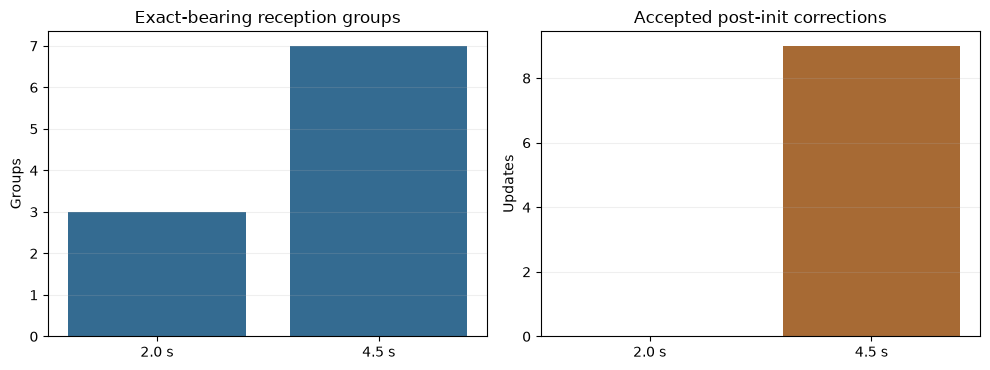

minimum unused recorded-source samples: 65831


In [2]:
assert controls[0]['confirmed'] == 'False' and controls[1]['confirmed'] == 'True'
assert int(controls[1]['accepted_update_count']) >= 3
assert int(controls[1]['accepted_post_init_frame_group_count']) >= 2
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
labels = [f"{row['duration_s']} s" for row in controls]
axes[0].bar(labels, [int(row['frame_group_count']) for row in controls], color='#346B91')
axes[0].set(title='Exact-bearing reception groups', ylabel='Groups')
axes[1].bar(labels, [int(row['accepted_update_count']) for row in controls], color='#A76A34')
axes[1].set(title='Accepted post-init corrections', ylabel='Updates')
for ax in axes: ax.grid(axis='y', alpha=.2)
fig.tight_layout()
plt.show()
print('minimum unused recorded-source samples:', min(int(row['remaining_samples']) for row in support))


### Held-out source sessions: bearing error and tracker availability

Each marker is one method/SNR/source-model result from an original evaluation session. Missing position/velocity errors and conditional coverage remain missing, never zero. Time availability uses zero-order hold between consecutive causal publications. Validity and covariance coverage are distinct denominators.


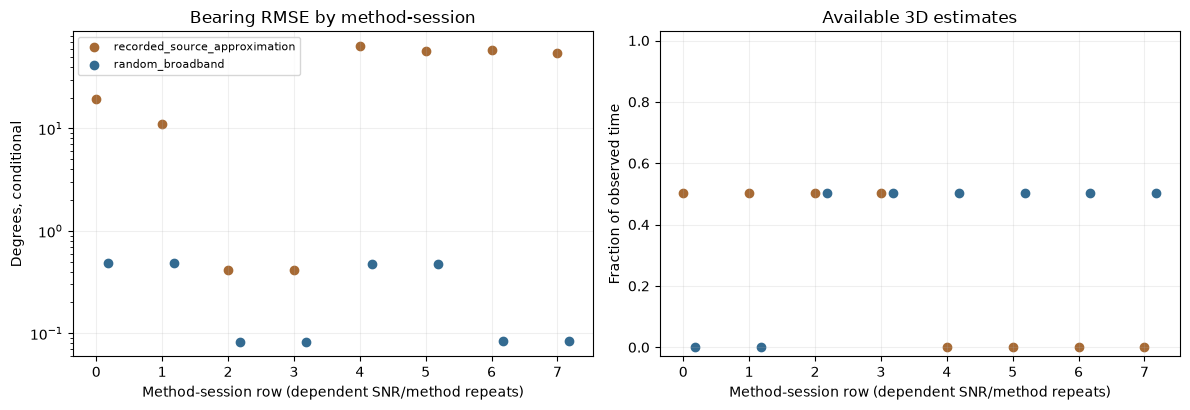

failure classes: {'computational_budget': 6, 'none': 10}
simeonradivoev-mini-quadcopter-raw-speed-takes -6.0 recorded_source_approximation all_6_equal_gcc_wls confirmed= False at= nan updates= 0 / 0 position_rmse_m= nan velocity_rmse_mps= nan available_time= 0.0 coverage_given_available_time= nan failure= computational_budget_exceeded
simeonradivoev-mini-quadcopter-raw-speed-takes -6.0 recorded_source_approximation equal_weight_srp_phat confirmed= False at= nan updates= 0 / 0 position_rmse_m= nan velocity_rmse_mps= nan available_time= 0.0 coverage_given_available_time= nan failure= computational_budget_exceeded
simeonradivoev-mini-quadcopter-raw-speed-takes -6.0 random_broadband all_6_equal_gcc_wls confirmed= True at= 2.5793125 updates= 9 / 2 position_rmse_m= 0.8920194763602559 velocity_rmse_mps= 0.7432479516575808 available_time= 0.5036354823073195 coverage_given_available_time= 0.992781520692974 failure= 
simeonradivoev-mini-quadcopter-raw-speed-takes -6.0 random_broadband equal_weig

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
colors = {'recorded_source_approximation':'#A76A34', 'random_broadband':'#346B91'}
sort_key = lambda r: (r['paired_session_id'], float(r['snr_db']), r['estimator_variant'])
for model, color in colors.items():
    subset = sorted((r for r in sessions if r['source_model_comparison'] == model), key=sort_key)
    time_subset = sorted((r for r in time_coverage if r['source_model_comparison'] == model), key=sort_key)
    assert [sort_key(r) for r in subset] == [sort_key(r) for r in time_subset]
    x = np.arange(len(subset)) + (0 if model == 'recorded_source_approximation' else .18)
    axes[0].scatter(x, [float(r['bearing_rmse_deg_conditional']) for r in subset], label=model, color=color)
    axes[1].scatter(x, [float(r['available_estimate_time_fraction']) for r in time_subset], label=model, color=color)
axes[0].set(title='Bearing RMSE by method-session', ylabel='Degrees, conditional', yscale='log')
axes[1].set(title='Available 3D estimates', ylabel='Fraction of observed time', ylim=(-.03, 1.03))
for ax in axes:
    ax.set_xlabel('Method-session row (dependent SNR/method repeats)')
    ax.grid(alpha=.2)
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()
print('failure classes:', dict(Counter(row['failure_class'] for row in sessions)))
coverage_lookup = {(r['paired_session_id'],r['snr_db'],r['estimator_variant'],r['source_model_comparison']):r for r in time_coverage}
for row in sessions:
    key = (row['paired_session_id'],row['snr_db'],row['estimator_variant'],row['source_model_comparison'])
    tc = coverage_lookup[key]
    print(row['paired_session_id'], row['snr_db'], row['source_model_comparison'], row['estimator_variant'],
          'confirmed=', row['final_confirmed'], 'at=', row['first_confirmation_time_s'],
          'updates=', row['accepted_update_count'], '/', row['rejected_update_count'],
          'position_rmse_m=', row['position_rmse_m_conditional'], 'velocity_rmse_mps=', row['velocity_rmse_mps_conditional'],
          'available_time=', tc['available_estimate_time_fraction'],
          'coverage_given_available_time=', tc['coverage_given_available_time'],
          'failure=', row['failure_reason'])


## Takeaways

The historical absence of confirmed tracking was a schedule-feasibility failure, independent of recorded-waveform quality. The corrected exact-bearing control demonstrates feasible causal confirmation and later updates. In audio evaluation, 10 method-session runs confirm and 6 hit the four-fit budget; the broadband/-6 dB miss shows that this cost cap can reject a good-bearing stream, so availability is reported alongside conditional accuracy. For the mini-quadcopter recording, bearing RMSE is roughly 55–64° in this longer run and all four recorded variants hit the budget. For the take-off/hover recording, recorded variants confirm but conditional position RMSE is roughly 12.6–18.0 m versus 0.1–0.9 m for available broadband controls. Coverage among valid publications can be high because recorded calibration R is broad; it is not proof of calibration with two held-out sessions. Frames/SNR repeats are dependent, and the budget bounds fit count rather than optimizer wall time. No absolute SPL, detection range or field-performance claim follows.
